# ARTI 308 – Lab 5: Feature Engineering (Classification)
## Order Status Prediction using a Talabat-style Orders Dataset

### Lab focus
This dataset is already clean (no missing values, no duplicate rows, consistent data types).  
In this lab, we focus on **feature engineering** for a classification task, not on data cleaning.

### Objective
Build a baseline model to predict `Order_Status` (Delivered, Cancelled, In Transit) and learn how feature engineering choices affect model performance and feature importance.

In this lab we will:
1) Load and inspect the dataset  
2) Define the target and select usable predictors (avoid leakage features)  
3) Engineer new features (time-based, price-based, distance-based)  
4) Encode categorical features  
5) Train a baseline **Random Forest** classifier  
6) Interpret performance and feature importance  

## 1. Setup and imports

In [149]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings('ignore')

## 2. Load the dataset

In [150]:
DATA_PATH = "talabat_enhanced_orders.csv"  # ensure the file is in the same folder as this notebook
df = pd.read_csv(DATA_PATH)

df.head(10)


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,Alexandria,Wallet,Delivered,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,Zagazig,Credit Card,Delivered,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,Assiut,Cash,In Transit,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,Mansoura,Cash,Delivered,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,Mansoura,Wallet,Delivered,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online
5,6,U7439,750,270,Sushi,3,205.44,2025-06-04 12:16:00,2025-06-04 12:45:00,29,Mansoura,Credit Card,Delivered,Bicycle,31.024140,31.387817,31.029004,31.373869,31.022573,31.380646,1.436807,Medium,Online
6,7,U8948,827,4,Sushi,1,133.94,2025-06-11 04:09:00,2025-06-11 04:49:00,40,Cairo,Wallet,Delivered,Bicycle,30.026723,31.249101,30.043525,31.233372,30.038769,31.231835,2.402167,Low,Online
7,8,U8672,908,109,Shawarma,5,404.80,2025-06-12 18:37:00,2025-06-12 19:18:00,41,Mansoura,Cash,Delivered,Bicycle,31.052547,31.392976,31.053352,31.362834,31.049187,31.373710,2.878434,High,Online
8,9,U2205,814,215,Pizza,1,101.03,2025-06-01 22:18:00,2025-06-01 23:05:00,47,Mansoura,Credit Card,Delivered,Motorbike,31.041945,31.375128,31.041036,31.385503,31.041062,31.368488,0.995562,Low,Online
9,10,U7411,362,416,Pizza,1,130.05,2025-06-09 00:18:00,2025-06-09 01:04:00,46,Cairo,Wallet,Delivered,Bicycle,30.052723,31.236077,30.025107,31.229281,30.062032,31.227642,3.130713,Low,Online


The first rows confirm that the dataset loaded correctly.  
Each row represents one food delivery order, including information about the customer, restaurant, driver, and order outcome (`Order_Status`).

## 3. Quick dataset checks (cleanliness confirmation)

In [151]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (100000, 23)

Missing values per column:


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


We confirm the dataset is clean: no missing values and no duplicated rows.  
Therefore, we will spend our effort on feature engineering rather than cleaning.

## 4. Target variable and class balance

In [152]:
target_col = "Order_Status"
df[target_col].value_counts()

Order_Status
Delivered     85197
Cancelled      9812
In Transit     4991
Name: count, dtype: int64

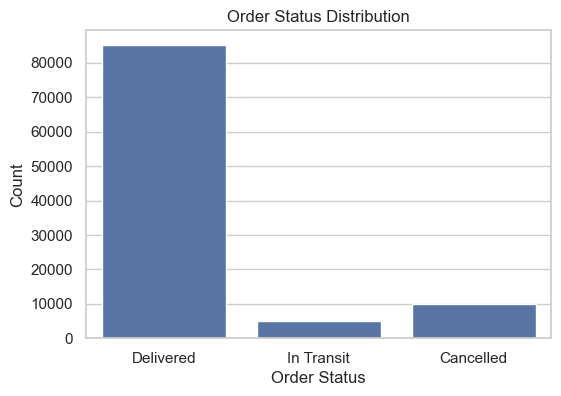

In [153]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

This bar chart shows whether the classes are balanced.  
If one class dominates, the model may learn to predict that class more often, so we must interpret accuracy carefully and also look at the confusion matrix.

## 5. Identify feature types

In [154]:
df.dtypes

Order_ID                       int64
User_ID                       object
Restaurant_ID                  int64
Driver_ID                      int64
Item_Name                     object
Quantity                       int64
Total_Price                  float64
Order_Time                    object
Delivery_Time                 object
Delivery_Duration_Minutes      int64
City                          object
Payment_Method                object
Order_Status                  object
Driver_Vehicle                object
Restaurant_Lat               float64
Restaurant_Lon               float64
Customer_Lat                 float64
Customer_Lon                 float64
Driver_Lat                   float64
Driver_Lon                   float64
Delivery_Distance_km         float64
Traffic_Level                 object
Driver_Availability           object
dtype: object

We have a mixture of numerical features (e.g., `Quantity`, `Total_Price`, distances) and categorical features (e.g., `City`, `Payment_Method`, `Traffic_Level`).  
This is a common real-world situation where feature engineering and encoding become essential.


## 6. Leakage awareness (important)

When designing a prediction task, we must avoid using features that would not be available at prediction time.

For example, if we want to predict the order status **right after the customer places the order**, we should not use:
- `Delivery_Time` (known only later)
- `Delivery_Duration_Minutes` (known only after delivery)

In this lab, we will **exclude** obvious leakage features and focus on information that is typically available early in the order lifecycle.


## 7. Feature engineering

### 7.1 Time-based features from `Order_Time`
We convert `Order_Time` into a datetime, then extract:
- hour of day  
- day of week  
- weekend flag  
- peak hour flag (example rule: lunch and dinner periods)


In [155]:
df_fe = df.copy()

# Parse time columns
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")

df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek  # Monday=0, Sunday=6
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5,6]).astype(int)

# # Simple peak-hour rule (you can adjust based on local context):
# # Lunch: 12-15, Dinner: 19-23
# df_fe["is_peak_hour"] = df_fe["order_hour"].isin(list(range(12,16)) + list(range(19,24))).astype(int)

# df_fe[["Order_Time","order_hour","order_dayofweek","is_weekend","is_peak_hour"]].head(10)


# Task 2: new rule, demand classified into high, moderate, low and quiet
conditions = [
    df_fe["order_hour"].between(12, 14) | df_fe["order_hour"].between(19, 21), # high demand
    df_fe["order_hour"].between(8, 11) | df_fe["order_hour"].between(15, 18),  # moderate demand
    df_fe["order_hour"].between(22, 23) | (df_fe["order_hour"] == 0) # low demand
]
choices = [3, 2, 1] # 0 for quiet

df_fe["demand_intensity"] = np.select(conditions, choices, default=0)

df_fe[["Order_Time","order_hour","order_dayofweek","is_weekend","demand_intensity"]].head(10)


,Order_Time,order_hour,order_dayofweek,is_weekend,demand_intensity
0,2025-06-16 08:32:00,8,0,0,2
1,2025-06-03 21:27:00,21,1,0,3
2,2025-06-01 14:48:00,14,6,1,3
3,2025-06-13 02:30:00,2,4,0,0
4,2025-06-06 09:48:00,9,4,0,2
5,2025-06-04 12:16:00,12,2,0,3
6,2025-06-11 04:09:00,4,2,0,0
7,2025-06-12 18:37:00,18,3,0,2
8,2025-06-01 22:18:00,22,6,1,1
9,2025-06-09 00:18:00,0,0,0,1


We transformed the original timestamp into multiple meaningful features.  
Models often learn better from these engineered features than from raw timestamps.


### 7.2 Price-based features
We create a feature that captures the price per item:
`price_per_item = Total_Price / Quantity`

This can help the model differentiate between an expensive order with few items and a cheaper order with many items.


In [156]:
df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]
df_fe[["Quantity","Total_Price","price_per_item"]].head(10)


,Quantity,Total_Price,price_per_item
0,3,273.72,91.24
1,3,365.82,121.94
2,3,401.94,133.98
3,2,221.18,110.59
4,5,355.55,71.11
5,3,205.44,68.48
6,1,133.94,133.94
7,5,404.80,80.96
8,1,101.03,101.03
9,1,130.05,130.05


##### Task 1: Distance to price ratio


In [157]:
df_fe["dist_price_ratio"] = df_fe["Delivery_Distance_km"] / (df_fe["Total_Price"] + 1)
df_fe[["Delivery_Distance_km", "Total_Price", "dist_price_ratio"]].head()

,Delivery_Distance_km,Total_Price,dist_price_ratio
0,1.666106,273.72,0.006065
1,2.738698,365.82,0.007466
2,2.929079,401.94,0.007269
3,0.677498,221.18,0.003049
4,1.994769,355.55,0.005595


`price_per_item` is a derived feature that may reflect restaurant type, item category, or order complexity.  
It is an example of business-driven feature engineering.


### 7.3 Optional: Haversine distance from GPS coordinates
The dataset already includes `Delivery_Distance_km`.  
However, if latitude/longitude columns exist, we can also compute an additional distance feature using the Haversine formula.

This section is **optional** and will only run if the coordinate columns exist.


In [158]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in kilometers."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

coord_cols = {"Restaurant_Lat","Restaurant_Lon","Customer_Lat","Customer_Lon"}
if coord_cols.issubset(set(df_fe.columns)):
    df_fe["haversine_rest_to_cust_km"] = haversine_km(
        df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"],
        df_fe["Customer_Lat"], df_fe["Customer_Lon"]
    )
    display(df_fe[["Delivery_Distance_km","haversine_rest_to_cust_km"]].head(10))
else:
    print("Coordinate columns not found. Skipping Haversine feature.")


,Delivery_Distance_km,haversine_rest_to_cust_km
0,1.666106,1.663239
1,2.738698,2.741931
2,2.929079,2.938058
3,0.677498,0.679441
4,1.994769,1.990872
5,1.436807,1.434924
6,2.402167,2.404753
7,2.878434,2.872665
8,0.995562,0.993613
9,3.130713,3.139677


If computed, `haversine_rest_to_cust_km` is a physics-based distance derived from coordinates.  
It can be used as an additional engineered feature, and it can also be compared with `Delivery_Distance_km` to understand how the dataset’s provided distance was generated.


### 7.4 Reducing high-cardinality categories (example: `Item_Name`)
`Item_Name` may have many unique values. If we one-hot encode all items, the feature space becomes huge.

A common feature engineering approach is to keep the most frequent categories and map the rest to `Other`.


In [159]:
if "Item_Name" in df_fe.columns:
    top_k = 20
    top_items = df_fe["Item_Name"].value_counts().head(top_k).index
    df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")
    print("Unique Item_Name:", df_fe["Item_Name"].nunique())
    print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())
    df_fe[["Item_Name","Item_Name_reduced"]].head(10)
else:
    print("Item_Name column not found.")


Unique Item_Name: 9
Unique Item_Name_reduced: 9


We reduced the cardinality of a text category feature.  
This often improves model stability and reduces overfitting, especially for baseline models.


## 8. Discretization (binning)

Discretization converts a continuous numerical feature into categories (bins).  
This can help some models capture non-linear relationships, and it also improves interpretability.

Here we discretize `Total_Price` into simple tiers.


In [160]:
df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["low","medium","high","very_high"]
)

df_fe[["Total_Price","price_tier"]].head(10)


,Total_Price,price_tier
0,273.72,high
1,365.82,high
2,401.94,high
3,221.18,medium
4,355.55,high
5,205.44,medium
6,133.94,medium
7,404.80,high
8,101.03,medium
9,130.05,medium


`price_tier` groups numeric values into understandable categories.  
This may help capture patterns such as higher cancellation rates for very expensive orders, if such a trend exists.


## 9. Prepare features for modeling

We now select our predictors.

We will drop:
- IDs that do not represent meaningful signals by themselves
- Obvious leakage features (`Delivery_Time`, `Delivery_Duration_Minutes`)

We will keep:
- early-available numeric and categorical variables
- engineered features


In [161]:
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
    "Order_Time", "Delivery_Time", "Delivery_Duration_Minutes",
    "Item_Name"  # we replaced it with Item_Name_reduced
]

# keep only columns that exist (safe for future versions of the dataset)
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (100000, 23)
y shape: (100000,)


,Quantity,Total_Price,City,Payment_Method,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,order_hour,order_dayofweek,is_weekend,demand_intensity,price_per_item,dist_price_ratio,haversine_rest_to_cust_km,Item_Name_reduced,price_tier
0,3,273.72,Alexandria,Wallet,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline,8,0,0,2,91.24,0.006065,1.663239,Fried Chicken,high
1,3,365.82,Zagazig,Credit Card,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online,21,1,0,3,121.94,0.007466,2.741931,Sandwich,high
2,3,401.94,Assiut,Cash,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online,14,6,1,3,133.98,0.007269,2.938058,Koshary,high
3,2,221.18,Mansoura,Cash,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online,2,4,0,0,110.59,0.003049,0.679441,Sushi,medium
4,5,355.55,Mansoura,Wallet,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online,9,4,0,2,71.11,0.005595,1.990872,Koshary,high


We prepared a feature matrix `X` and a target vector `y`.  
The feature matrix includes engineered features such as time-based indicators, price per item, and reduced item category.


## 10. Split into train and test sets

In [162]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (80000, 23)
Test size: (20000, 23)


We use stratified splitting to keep class proportions similar in train and test sets.  
This makes evaluation more reliable for classification problems with imbalanced classes.


## 11. Encoding and baseline model (Random Forest)

### Why encoding?
Machine learning models require numerical input.  
Categorical variables must be converted into numbers. Here we use **One-Hot Encoding** for nominal categories.

### Why Random Forest for this lab?
We use Random Forest as a baseline because:
- it handles mixed features well
- it is robust for teaching purposes
- it provides feature importance to help us interpret engineered features


In [163]:
# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model


Categorical columns: ['City', 'Payment_Method', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability', 'Item_Name_reduced', 'price_tier']
Numeric columns: ['Quantity', 'Total_Price', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'order_hour', 'order_dayofweek', 'is_weekend', 'demand_intensity', 'price_per_item', 'dist_price_ratio', 'haversine_rest_to_cust_km']


,steps,"[('preprocess', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 12. Train the model and evaluate

In [164]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8519

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



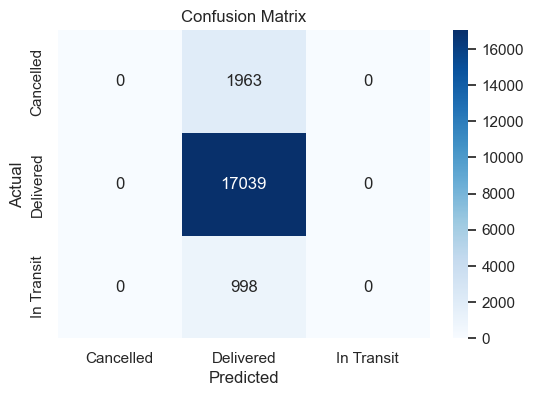

In [165]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Accuracy gives a general sense of performance, but the classification report is more informative.  
Precision answers: when the model predicts a class, how often is it correct?  
Recall answers: out of all real cases of a class, how many did the model find?

The confusion matrix shows which classes the model confuses most often.


## 13. Feature importance (What mattered the most?)

Random Forest provides a built-in feature importance score.  
Because we used one-hot encoding, each categorical value becomes its own feature.  
We will extract the final feature names and plot the top importances.


In [166]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)


,feature,importance
44,price_per_item,0.065589
38,Driver_Lon,0.064978
37,Driver_Lat,0.064933
34,Restaurant_Lon,0.064759
36,Customer_Lon,0.064735
33,Restaurant_Lat,0.064409
35,Customer_Lat,0.064315
32,Total_Price,0.063082
45,dist_price_ratio,0.062986
46,haversine_rest_to_cust_km,0.062092


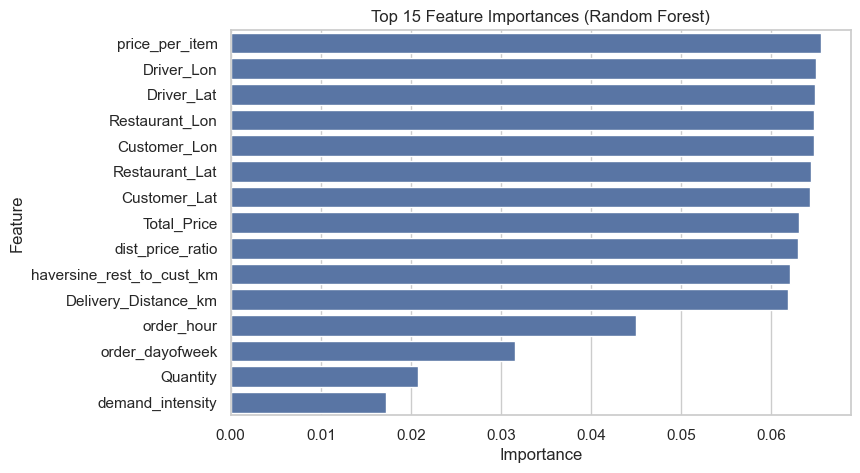

In [167]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


This chart helps us understand which engineered and original features contributed most to predicting `Order_Status`.  
A high importance score suggests the feature provides useful signal, but it does not automatically imply a causal relationship.


## 14. Optional: Feature selection using SelectFromModel

We can select a subset of features using model-based selection.  
This is optional and mainly used to illustrate the concept of feature selection after feature engineering.


In [168]:
from sklearn.feature_selection import SelectFromModel

# Build a new pipeline that selects features based on RF importances
selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"  # keep features above the median importance
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))


Accuracy (with feature selection): 0.8519

Classification Report (with feature selection):
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



If performance stays similar, feature selection may help simplify the model with minimal accuracy loss.  
If performance drops, it may indicate that important information was removed.

## 15. Student tasks

### Task 1
Create one new engineered feature that you believe will help predict `Order_Status`.  
Write one paragraph justifying your choice.

A dist_price_ratio feature was added.
It will determine how efficient it would be to fulfill an order. If the distance is high with a low price, there would be a potentially low revenue earned at a high time and cost investment, which makes the order less attractive for delivery drivers to accept. Should the opposite occur, in which the price is very high with a short distance, the restaurant may not have enough time to prepare the large order before the driver arrives, which can cause long wait times or order cancellations. By creating this feature, the model would understand the delivery effort vs reward concept, which is a stronger predictor of potential cancellations or delays over viewing price or distance alone.

### Task 2
Try a different rule for `is_peak_hour` and discuss whether performance changes.

| rule | accuracy | top feature 1 | top feature 2 | top feature 3 |
|-------|----------|---------------|---------------|---------------|
| original rule  | 0.8519 | price_per_item (0.066192) | Driver_Lon (0.065526) | Customer_Lat (0.065284) |
| new rule | 0.8519 | price_per_item (0.065589) | Driver_Lon (0.064978) | Driver_Lat (0.064933) |


The top features have changed while the accuracy has remained unaffected

### Task 3
Change `top_k` in `Item_Name_reduced` (for example 10, 30, 50) and compare:
- accuracy
- top feature importances

| top_k | accuracy | top feature 1 | top feature 2 | top feature 3 |
|-------|----------|---------------|---------------|---------------|
|20  | 0.8519 | price_per_item (0.065589) | Driver_Lon (0.064978) | Driver_Lat (0.064933) |
| 5 | 0.8519 | price_per_item (0.067059) | Driver_Lon (0.066686) | Driver_Lat (0.066800) |
| 30 | 0.8519 | price_per_item (0.065589) | Driver_Lon (0.064978) | Driver_Lat (0.064933) |
| 50 | 0.8519 | price_per_item (0.065589) | Driver_Lon (0.064978) | Driver_Lat (0.064933) |


### Task 4
Run the optional feature selection section and explain whether it was beneficial in your case.

There was no difference in the results


## Wrap-up
In this lab, the dataset was already clean, so our focus was on feature engineering.  
We engineered time-based, price-based, and category-reduction features, then evaluated a baseline classifier and interpreted feature importance.
